#  Experiment 4 & 5 | Regression Model Development

In [ ]:
import pandas as pd 
data = pd.read_csv(r"../datasets\city_day.csv")
data = data.dropna(subset=['AQI'])
# outlier detection and removal
data = data.dropna()
# X PM2.5...Xylene 
X = data.iloc[:, 2:14]
Y = data.iloc[:, 14]
X.head()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene
2123,81.40,124.50,1.44,20.50,12.08,10.72,0.12,15.24,127.09,0.20,6.50,0.06
2124,78.32,129.06,1.26,26.00,14.85,10.28,0.14,26.96,117.44,0.22,7.95,0.08
2125,88.76,135.32,6.60,30.85,21.77,12.91,0.11,33.59,111.81,0.29,7.63,0.12
2126,64.18,104.09,2.56,28.07,17.01,11.42,0.09,19.00,138.18,0.17,5.02,0.07
2127,72.47,114.84,5.23,23.20,16.59,12.25,0.16,10.55,109.74,0.21,4.71,0.08


Mean squared error:  651.3567823009216
R2 score:  0.9217139055744
Mean absolute error:  18.153468625461
RMSE:  5.051899878964706


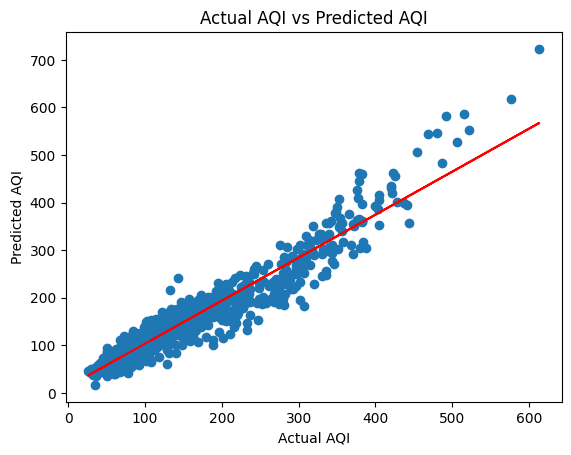

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

model = LinearRegression()
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)

print("Mean squared error: ", mean_squared_error(Y_test, Y_pred))
print("R2 score: ", r2_score(Y_test, Y_pred))
print("Mean absolute error: ", mean_absolute_error(Y_test, Y_pred))
print("RMSE: ", np.sqrt(root_mean_squared_error(Y_test, Y_pred))) 

plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual AQI vs Predicted AQI")
m, b = np.polyfit(Y_test, Y_pred, 1)
plt.plot(Y_test, m*Y_test + b, color='red')
plt.show()


Mean squared error:  423.6233120192308
R2 score:  0.9490850245107274
Mean absolute error:  13.860160256410255
RMSE:  4.5367512006697


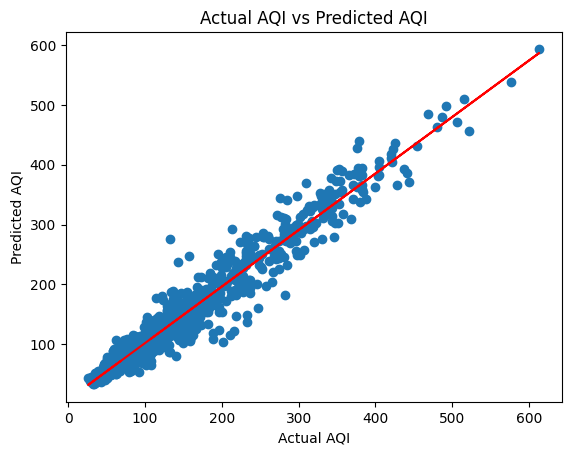

In [5]:
# RandomForest Regressor
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)

print("Mean squared error: ", mean_squared_error(Y_test, Y_pred))
print("R2 score: ", r2_score(Y_test, Y_pred))
print("Mean absolute error: ", mean_absolute_error(Y_test, Y_pred))
print("RMSE: ", np.sqrt(root_mean_squared_error(Y_test, Y_pred)))

plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual AQI vs Predicted AQI")
m, b = np.polyfit(Y_test, Y_pred, 1)
plt.plot(Y_test, m*Y_test + b, color='red')
plt.show()

Accuracy:  0.8197115384615384
Precision:  0.820178531558966
Recall:  0.8197115384615384
Confusion Matrix: 
 [[ 65   0   0  29   0   0]
 [  0 438  22  49   0   0]
 [  0  34  83   0   0  15]
 [  9  43   0 359   0   0]
 [  0   0   1   0  13   9]
 [  0   0  12   0   2  65]]


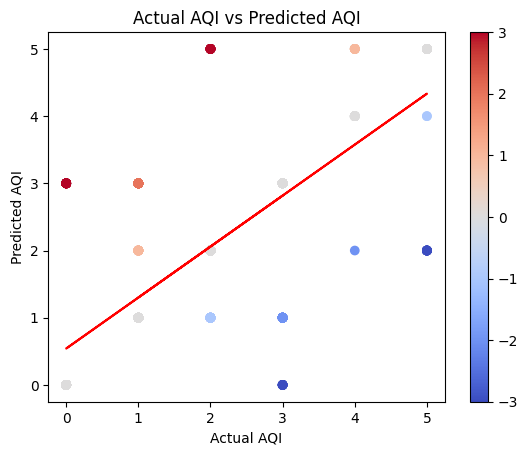

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
data = pd.read_csv(r"../datasets\city_day.csv")
data = data.dropna(subset=['AQI'])
data = data.dropna()
data['AQI_Bucket'] = pd.Categorical(data['AQI_Bucket'])
data['AQI_Bucket'] = data['AQI_Bucket'].cat.codes
X = data.iloc[:, 2:14]
Y = data.iloc[:, 15]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)

print("Accuracy: ", accuracy_score(Y_test, Y_pred))
print("Precision: ", precision_score(Y_test, Y_pred, average='weighted'))
print("Recall: ", recall_score(Y_test, Y_pred, average='weighted'))
print("Confusion Matrix: \n", confusion_matrix(Y_test, Y_pred))

# coloured distinct scatter plot
plt.scatter(Y_test, Y_pred, c=Y_pred-Y_test, cmap='coolwarm')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual AQI vs Predicted AQI")
m, b = np.polyfit(Y_test, Y_pred, 1)
plt.plot(Y_test, m*Y_test + b, color='red')
plt.colorbar()
plt.show()